In [1]:
import sys
import os
# This is to ensure that the spack-installed packages are available in the environment
sys.path.append('/mnt/system/spack_nfs/spack_24Q2/spack_main/var/spack/environments/python-3p9-torch2-cuda12-24Q2/.spack-env/view/lib/python3.11/site-packages')
sys.path.append(os.path.dirname(os.path.abspath(os.getcwd())))
sys.path.append(os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), "collective_encoder"))

import numpy as np
import matplotlib.pyplot as plt 
from matplotlib import cm
import MDAnalysis as mda
from MDAnalysis.analysis.dihedrals import Ramachandran

from collective_encoder.utils import compute_mfpt_matrix

from funcs import *


In [2]:
run_folder = 'ala2/solvated/273K/ala2_100ns'
phi, psi = calculate_dihedrals(run_folder)
print(phi.shape, psi.shape)

  0%|          | 0/100001 [00:00<?, ?it/s]

(100001,) (100001,)


/mnt/projects/sne/Gohar/software_deck/pyenv-ml/lib/python3.12/site-packages/MDAnalysis/analysis/dihedrals.py:574: DeprecationWarning: The `angle` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.angles` instead
  warnings.warn(wmsg, DeprecationWarning)


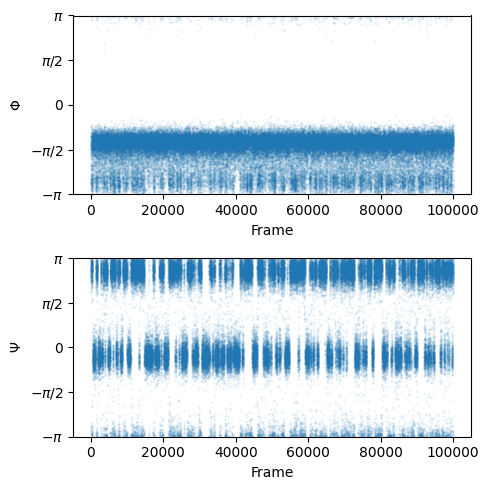

In [3]:
save_path = os.path.join(run_folder, '..','population_plot.png')
population_plot(psi, phi, save_path)

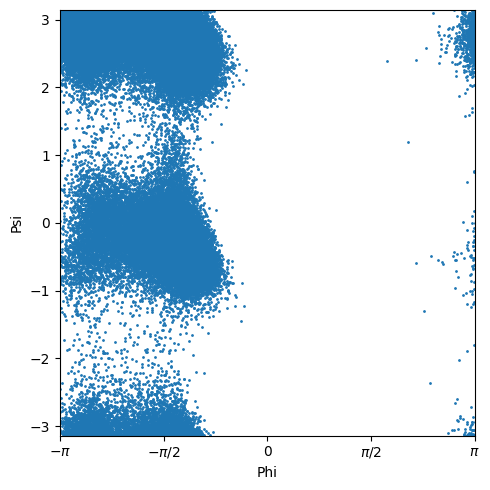

In [4]:
save_path = os.path.join(run_folder, '..','rama_plot.png')
rama_plot(psi, phi, save_path)

# Identify metastable states using BFGS solvers

In [5]:
sigma = 0.2 # bandwidth for KDE
bin_x = 200
bin_y = 200
minima_tolerance = 0.15
n_BFGS_runs = 100

kde, min_points = run_bfgs(phi, psi, 
                           sigma, bin_x, bin_y, 
                           minima_tolerance, n_BFGS_runs)


Number of local minima found: 10
[[ 3.0362149  -3.03328321]
 [-1.30498199 -0.33874305]
 [-1.27433444  2.67654102]
 [-2.68055534  2.77697521]
 [ 3.05412571  2.74855231]
 [ 3.03911474 -0.4667957 ]
 [ 2.12899981  1.19984163]
 [-1.48012157 -3.01632332]
 [-2.64268838 -2.99860812]
 [ 3.02758757 -1.89620497]]


In [6]:
min_points = sort_minima_by_depth(kde, min_points)

Objective values at minima: [ 6.68266923  0.65800505  0.64596491  1.57980997  4.39429115  6.99332714
 10.13191571  3.01905945  3.28327168  9.24286811]
Sorted objective values at minima:
 [ 0.64596491  0.65800505  1.57980997  3.01905945  3.28327168  4.39429115
  6.68266923  6.99332714  9.24286811 10.13191571]
Sorted minima points:
 [[-1.27433444  2.67654102]
 [-1.30498199 -0.33874305]
 [-2.68055534  2.77697521]
 [-1.48012157 -3.01632332]
 [-2.64268838 -2.99860812]
 [ 3.05412571  2.74855231]
 [ 3.0362149  -3.03328321]
 [ 3.03911474 -0.4667957 ]
 [ 3.02758757 -1.89620497]
 [ 2.12899981  1.19984163]]


In [7]:
Xgrid, Ygrid, fes = compute_fes(kde, bin_x, bin_y)

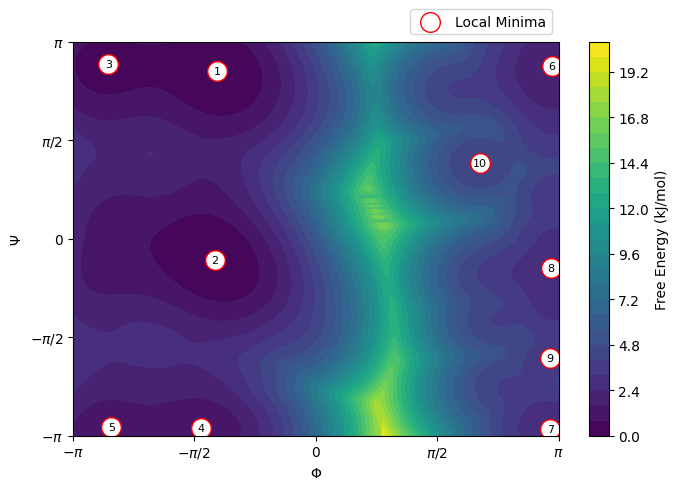

In [8]:
save_path = os.path.join(run_folder, '..', 'plot_fes.png')
plot_fes(Xgrid, Ygrid, fes, min_points, save_path=save_path)

In [10]:
# states 
selected = [a for a in range(len(min_points))] # choose which states to consider
lag_time = 1
minima, transition_counts, transition_matrix, mfpt_matrix = calculate_mfpt(phi, psi, min_points, selected, lag_time)


Selected states: [[ 2.12899981  1.19984163]
 [-1.27433444  2.67654102]
 [-1.30498199 -0.33874305]
 [-2.68055534  2.77697521]
 [-1.48012157 -3.01632332]
 [-2.64268838 -2.99860812]
 [ 3.05412571  2.74855231]
 [ 3.0362149  -3.03328321]
 [ 3.03911474 -0.4667957 ]
 [ 3.02758757 -1.89620497]]


In [11]:
plot_mfpt_matrix(minima,
                 mfpt_matrix,
                 transition_counts,
                 transition_matrix,
                 selected,
                 save_path=os.path.join(run_folder,'..', 'mfpt_matrix.png'),
                 lag_time=lag_time)

0.0 0.9921231988302714


ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x7f83da9a7740> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 1000x500 with 4 Axes>